In [1]:
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = ROOT / "data" / "raw" / "EuroSAT_RGB" / "EuroSAT_RGB"

print("Project root:", ROOT)
print("Dataset path:", DATA_DIR)
print("Dataset exists:", DATA_DIR.exists())

Project root: c:\Users\original store\Desktop\DEPI\satellite_empty
Dataset path: c:\Users\original store\Desktop\DEPI\satellite_empty\data\raw\EuroSAT_RGB\EuroSAT_RGB
Dataset exists: True


## 1.Dataset Overview

The first step of the initial inspection is to understand the overall structure of the EuroSAT RGB dataset. This includes determining the total number of available images, identifying the number of land-cover classes, and verifying the class names.

This overview provides a baseline for the subsequent data-quality checks, including the detection of corrupted images and the assessment of class distribution.

In [2]:
from PIL import Image

# Image extensions we expect in the dataset
image_extensions = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}

# Find all image files
image_files = [
    path for path in DATA_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in image_extensions
]

# Get class names from folder names
classes = sorted({
    path.parent.name
    for path in image_files
})

print("Total images:", len(image_files))
print("Number of classes:", len(classes))
print("\nClasses:")
for class_name in classes:
    print("-", class_name)

Total images: 27000
Number of classes: 10

Classes:
- AnnualCrop
- Forest
- HerbaceousVegetation
- Highway
- Industrial
- Pasture
- PermanentCrop
- Residential
- River
- SeaLake


In [3]:
from collections import Counter

# Count the number of images in each class
class_counts = Counter(path.parent.name for path in image_files)

print("Images per class:\n")

for class_name in sorted(class_counts):
    print(f"{class_name}: {class_counts[class_name]}")

Images per class:

AnnualCrop: 3000
Forest: 3000
HerbaceousVegetation: 3000
Highway: 2500
Industrial: 2500
Pasture: 2000
PermanentCrop: 2500
Residential: 3000
River: 2500
SeaLake: 3000


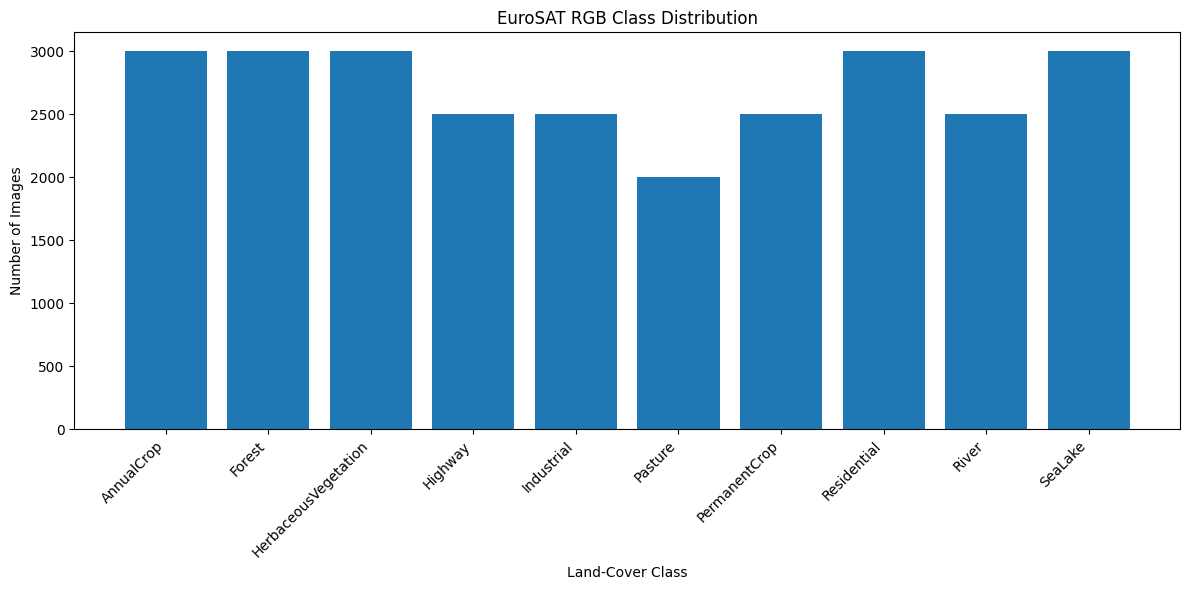

In [4]:
import matplotlib.pyplot as plt

# Prepare class names and their image counts
class_names = sorted(class_counts)
counts = [class_counts[class_name] for class_name in class_names]

# Create the class distribution plot
plt.figure(figsize=(12, 6))
plt.bar(class_names, counts)

plt.title("EuroSAT RGB Class Distribution")
plt.xlabel("Land-Cover Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Class Distribution – Initial Observation

The EuroSAT RGB dataset contains 27,000 images distributed across 10 land-cover classes. The number of images per class ranges from 2,000 to 3,000.

The `Pasture` class contains the fewest images (2,000), while `AnnualCrop`, `Forest`, `HerbaceousVegetation`, `Residential`, and `SeaLake` each contain 3,000 images.

Therefore, the dataset is not perfectly balanced across all classes. However, the difference between the largest and smallest classes is relatively moderate, with the smallest class containing approximately two-thirds of the number of images in the largest classes.

This class distribution should be considered when preparing the dataset for model training, as differences in class representation may affect model performance across individual classes.

## 2. Missing and Corrupted Images

After examining the class distribution, the next step is to assess the integrity of the raw image files. Since this is an image dataset, missing values are primarily interpreted as missing image files or images that cannot be successfully read.

Each image file will therefore be tested to determine whether it can be opened and verified as a valid image. Any unreadable or corrupted files will be recorded for further investigation.


In [5]:
from PIL import Image

corrupted_images = []

for image_path in image_files:
    try:
        with Image.open(image_path) as img:
            img.verify()
    except Exception as e:
        corrupted_images.append((image_path, str(e)))

print("Total image files checked:", len(image_files))
print("Corrupted/unreadable images:", len(corrupted_images))

Total image files checked: 27000
Corrupted/unreadable images: 0


### Image Integrity – Findings

The integrity check was performed on all 27,000 image files in the dataset. No corrupted or unreadable images were detected during the automated verification process.

**Result:** 27,000 images checked, with 0 corrupted or unreadable files identified.

This indicates that all image files passed the basic file-readability check and no immediate data integrity issues were detected at this stage.


## 3. Visual Inspection for Potentially Mislabeled Data

Automated checks can verify whether image files are readable, but they cannot reliably determine whether an image has been assigned to the correct land-cover class.

To identify potential labeling inconsistencies, a random sample of images from each class will be visually inspected. The purpose of this step is to identify obvious cases where the visual content of an image does not appear to correspond to its assigned class.

This is an initial screening rather than a complete manual validation of all 27,000 images.


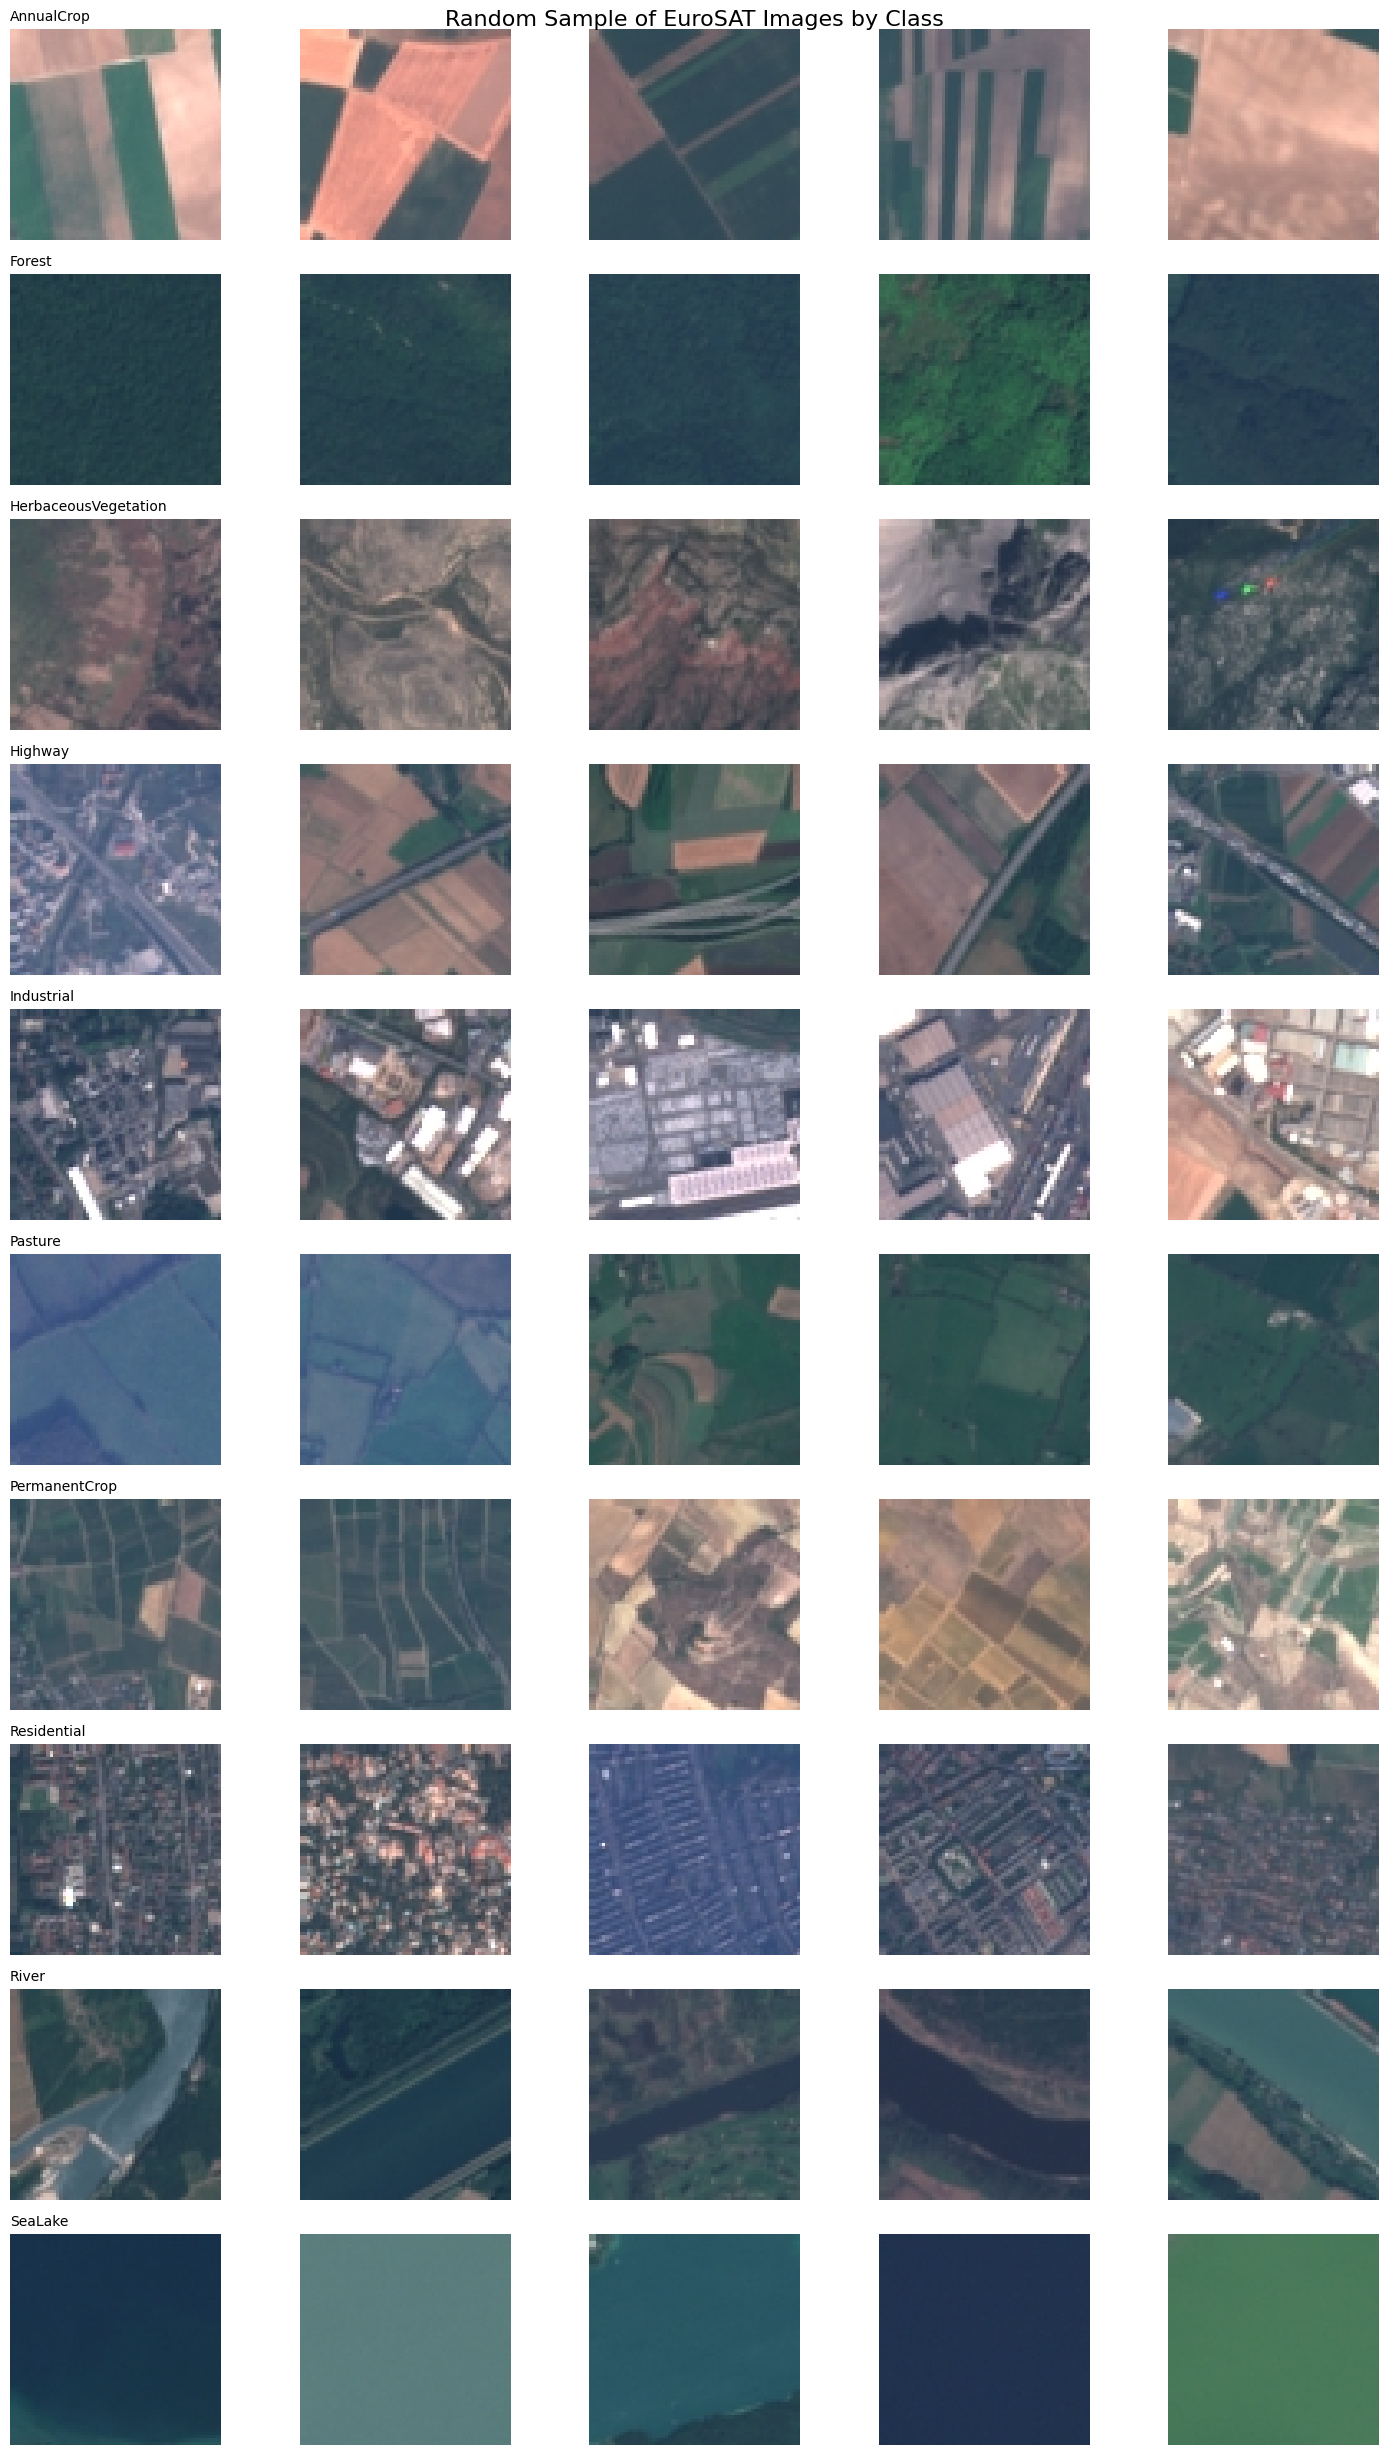

In [7]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Number of samples to display from each class
samples_per_class = 5

# Create a reproducible random generator
random.seed(34)

fig, axes = plt.subplots(
    len(class_names),
    samples_per_class,
    figsize=(15, 25)
)

for row, class_name in enumerate(class_names):
    # Get all images belonging to this class
    class_images = [
        path for path in image_files
        if path.parent.name == class_name
    ]

    # Randomly select samples
    samples = random.sample(class_images, samples_per_class)

    for col, image_path in enumerate(samples):
        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(class_name, loc="left", fontsize=10)

plt.suptitle(
    "Random Sample of EuroSAT Images by Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Visual Inspection – Findings

A random sample of 5 images from each of the 10 land-cover classes was visually inspected, resulting in a total of 50 inspected images.

The sampled images appeared visually consistent with their assigned class labels. No obvious labeling inconsistencies were identified during this initial visual inspection.

It should be noted that this assessment was performed on a sample of the dataset and therefore does not constitute a complete manual validation of all 27,000 images.


## 5. Overall Initial Findings

The initial inspection of the EuroSAT RGB dataset was conducted to assess its basic integrity, class distribution, and potential labeling inconsistencies before proceeding to further data preparation and model development.

| Inspection                  | Method                                          | Result                                       |
| --------------------------- | ----------------------------------------------- | -------------------------------------------- |
| Dataset size                | Enumeration of image files                      | 27,000 images across 10 classes              |
| Image integrity             | Automated image verification                    | 0 corrupted or unreadable images detected    |
| Class distribution          | Class-wise image counting                       | 2,000–3,000 images per class                 |
| Potentially mislabeled data | Visual inspection of 5 random samples per class | No obvious labeling inconsistencies observed |

Overall, the dataset passed the initial image integrity checks. The class distribution is not perfectly balanced, with the number of images per class ranging from 2,000 to 3,000. The visual inspection of the sampled images did not reveal any obvious labeling inconsistencies.

These findings provide an initial assessment of the raw dataset and can be used to guide the subsequent data preparation and model development stages.
